In [1]:
from google.colab import files
uploaded = files.upload()

Saving taylor_swift_tweets.xlsx to taylor_swift_tweets.xlsx


In [2]:
# =========================
# 1. Install Required Libraries
# =========================
!pip install pandas scikit-learn openpyxl

# =========================
# 2. Import Libraries
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, accuracy_score

# =========================
# 3. Upload Dataset
# =========================
from google.colab import files
uploaded = files.upload()

# Load Excel file
df = pd.read_excel("taylor_swift_tweets.xlsx")

print("Dataset Preview:")
print(df.head())

# =========================
# 4. Preprocessing
# =========================
# Convert to lowercase
df['Tweet'] = df['Tweet'].str.lower()

# Remove nulls if any
df = df.dropna()

# =========================
# 5. Split Dataset (80/20)
# =========================
X = df['Tweet']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 6. Convert Text to Numerical (TF-IDF)
# =========================
vectorizer = TfidfVectorizer(stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# =========================
# 7. Train Models
# =========================

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

# SVM
svm = SVC()
svm.fit(X_train_vec, y_train)

# Logistic Regression
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_vec, y_train)

# =========================
# 8. Predictions
# =========================
nb_pred = nb.predict(X_test_vec)
svm_pred = svm.predict(X_test_vec)
lr_pred = lr.predict(X_test_vec)

# =========================
# 9. Evaluation
# =========================

print("🔵 Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

print("\n🟢 SVM Results:")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

print("\n🟡 Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Saving taylor_swift_tweets.xlsx to taylor_swift_tweets (1).xlsx
Dataset Preview:
   Tweet_ID                                              Tweet Sentiment
0         1  Taylor Swift never misses, every song is a mas...  Positive
1         2  Listening to Taylor Swift makes my day instant...  Positive
2         3      Her lyrics hit so deep, she’s truly a genius.  Positive
3         4  Taylor Swift’s concert was the best night of m...  Positive
4         5             No one writes songs like Taylor Swift.  Positive
🔵 Naive Bayes Results:
Accuracy: 0.35
              precision    recall  f1-score   support

    Negative       0.33      0.14      0.20         7
     Neutral       0.27      1.00      0.42         4
    Positive       1.00      0.22      0.36         9

    accuracy                           0.35        20
   macro avg       0.53      0.46      0.33        20
weighted avg       0.62      0.35      0.32        20


🟢 SVM Results:
Accuracy: 0.35
              precision    reca

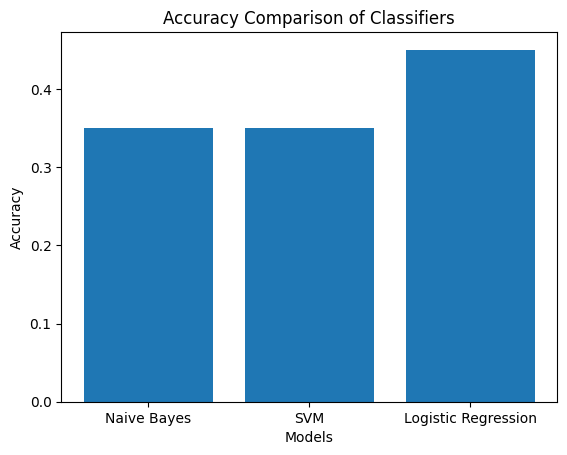

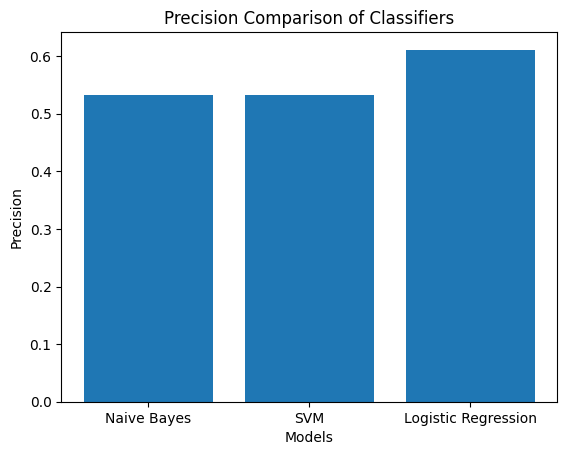

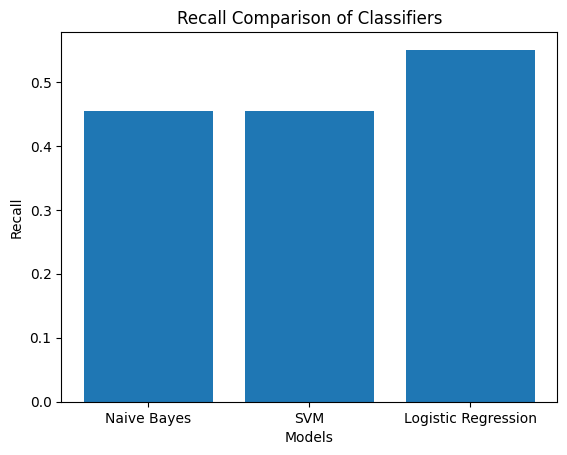

In [3]:
# =========================
# GRAPH SECTION (FINAL OUTPUT)
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

# Calculate Accuracy
nb_acc = accuracy_score(y_test, nb_pred)
svm_acc = accuracy_score(y_test, svm_pred)
lr_acc = accuracy_score(y_test, lr_pred)

# Calculate Precision (macro)
nb_prec = precision_score(y_test, nb_pred, average='macro')
svm_prec = precision_score(y_test, svm_pred, average='macro')
lr_prec = precision_score(y_test, lr_pred, average='macro')

# Calculate Recall (macro)
nb_rec = recall_score(y_test, nb_pred, average='macro')
svm_rec = recall_score(y_test, svm_pred, average='macro')
lr_rec = recall_score(y_test, lr_pred, average='macro')

# Model Names
models = ['Naive Bayes', 'SVM', 'Logistic Regression']

# =========================
# 1. Accuracy Graph
# =========================
accuracies = [nb_acc, svm_acc, lr_acc]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison of Classifiers')
plt.show()


# =========================
# 2. Precision Graph
# =========================
precisions = [nb_prec, svm_prec, lr_prec]

plt.figure()
plt.bar(models, precisions)
plt.xlabel('Models')
plt.ylabel('Precision')
plt.title('Precision Comparison of Classifiers')
plt.show()


# =========================
# 3. Recall Graph
# =========================
recalls = [nb_rec, svm_rec, lr_rec]

plt.figure()
plt.bar(models, recalls)
plt.xlabel('Models')
plt.ylabel('Recall')
plt.title('Recall Comparison of Classifiers')
plt.show()